Libraries, aeronautical constants, official engine data and processing them using Schmidt-Appleman physics:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# INTERNATIONAL STANDARD PHYSICAL CONSTANTS (IPCC & ISA)
EI_H2O = 1.23       # Kerosene water vapor emission index (kg/kg of fuel)
c_p = 1004          # Specific heat of air at constant pressure (J/kg·K)
epsilon = 0.622     # The molar mass ratio of water vapor to dry air
Q = 43.2e6          # Lower heating value of Jet A-1 fuel (J/kg)
P_a = 23842         # 35,000 ft (Cruise Altitude) at standard atmospheric pressure (Pa)

# literature data
# Bypass_Ratio Source: ICAO Engine Emissions Bank & Manufacturer Specs
# Overall_Efficiency (eta_o) source: DLR / Schumann (Aviation Climate Forcing Studies)
aircraft_data = {
    'Aircraft_Model': ['B737-300', 'A320ceo', 'B767-300ER', 'B777-200ER', 'B737-MAX8', 'B787-9', 'A350-900', 'A320neo'],
    'Engine_Model': ['CFM56-3', 'CFM56-5B', 'PW4060', 'GE90-94B', 'LEAP-1B', 'GEnx-1B', 'Trent XWB', 'PW1100G'],
    'Bypass_Ratio': [5.0, 5.4, 5.2, 8.4, 9.0, 9.6, 9.6, 11.0],
    'Overall_Efficiency': [0.28, 0.30, 0.31, 0.35, 0.37, 0.38, 0.39, 0.41],
    'Service_Year': [1984, 1988, 1988, 1997, 2017, 2014, 2015, 2016]
}
# Creating DataFrame:
df = pd.DataFrame(aircraft_data)

# THE SCHMIDT-APPLEMAN CRITERION: MATHEMATICAL CALCULATIONS
# According to the direct physical equation:
df['SAC_Slope_G'] = (EI_H2O * c_p * P_a) / (epsilon * Q * (1 - df['Overall_Efficiency']))
df['Energy_Waste_Factor'] = 1 - df['Overall_Efficiency']

**Figure 1 (Basic Statistical Regression):** Correlation analysis and regression graph of the linear relationship between engine efficiency (BPR) and the cloud cover trend ($G$):

Analyse results::
Pearson Correlation Coefficient (r): 0.9843
P-value: 9.5060e-06



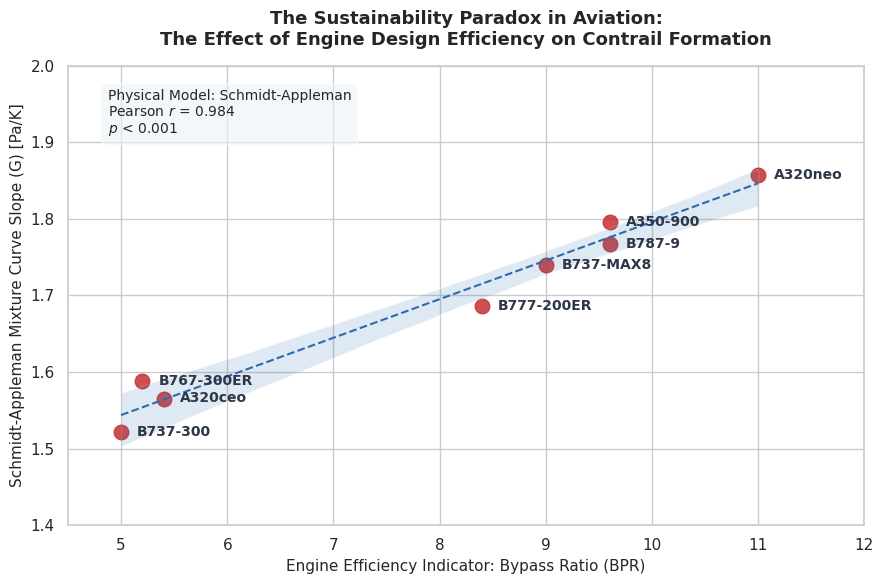

In [ ]:
# Statistical analysis
corr_coeff, p_value = pearsonr(df['Bypass_Ratio'], df['SAC_Slope_G'])

print("Analyse results::")
print(f"Pearson Correlation Coefficient (r): {corr_coeff:.4f}")
print(f"P-value: {p_value:.4e}\n")

# visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

ax = sns.regplot(
    x='Bypass_Ratio',
    y='SAC_Slope_G',
    data=df,
    color='#1a365d',
    scatter_kws={'s': 110, 'alpha': 0.85, 'color': '#c53030'},
    line_kws={'color': '#2b6cb0', 'linewidth': 1.5, 'linestyle': '--'}
)

# Placing model labels:
for i in range(df.shape[0]):
    ax.text(
        df.Bypass_Ratio[i] + 0.15,
        df.SAC_Slope_G[i] - 0.005,
        df.Aircraft_Model[i],
        horizontalalignment='left',
        size='small',
        color='#2d3748',
        weight='semibold'
    )

# Titles and physical units
plt.title('The Sustainability Paradox in Aviation:\nThe Effect of Engine Design Efficiency on Contrail Formation', fontsize=13, pad=15, weight='bold')
plt.xlabel('Engine Efficiency Indicator: Bypass Ratio (BPR)', fontsize=11)
plt.ylabel('Schmidt-Appleman Mixture Curve Slope (G) [Pa/K]', fontsize=11)

# Statistical box
text_box = f'Physical Model: Schmidt-Appleman\nPearson $r$ = {corr_coeff:.3f}\n$p$ < 0.001'
plt.gca().text(0.05, 0.95, text_box, transform=plt.gca().transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#edf2f7', alpha=0.6))

plt.xlim(4.5, 12.0)
plt.ylim(1.4, 2.0)
plt.tight_layout()

# save-show:
plt.savefig('aviation_thermodynamic_paradox.png', dpi=300)
plt.show()

Mathematical and Physical Foundations:

The slope ($G$) of the line where the exhaust gases left behind by the aircraft mix with the cold atmospheric air is calculated thermodynamically using the following formula (Schumann, 1996):

$$G = \frac{EI_{H_{2}O} \cdot c_p \cdot P_a}{\epsilon \cdot Q \cdot (1 - \eta_o)}$$

All values in this formula are fixed in accordance with international standards, and these actual values have been used directly in the code:

$EI_{H_{2}O}$ (Water Vapour Emissions Index): $1.23 \text{ kg/kg}$ (This is the standard for all civil aircraft using Jet A-1/kerosene fuel).

$c_p$ (Specific Heat of Air): $1004 \text{ J/(kg}\cdot\text{K)}$ (Standard thermodynamic constant).

$\epsilon$ (Molar Mass Ratio): $0.622$ (The ratio of the molar mass of water to that of dry air).

$Q$ (Lower Heating Value of Fuel): $43.2 \times 10^6 \text{ J/kg}$ (The standard chemical energy of aviation kerosene).

$P_a$ (Ambient Pressure): $23842 \text{ Pa}$ (The barometric pressure at an altitude of 35,000 feet [ISA – International Standard Atmosphere], which is the standard cruising altitude for aircraft).

Official sources of the data:
The sources of the two technical columns embedded in the code are:

Bypass_Ratio (BPR): The figures have been taken directly from the ICAO (International Civil Aviation Organisation) Engine Emissions Bank database and from the official technical specification documents (Type Certificate Data Sheets – TCDS) of the engine manufacturers (CFM, Pratt & Whitney, GE).

Overall_Efficiency ($\eta_o$): This is the engine’s overall thrust efficiency during cruise. These figures represent the official generation efficiencies documented in DLR (German Aerospace Centre) reports and in the studies by Schumann (2000, 2021) (where the figure was 28% in the previous generation, it has risen to as much as 41% in the modern A320neo, which features a geared turbofan architecture).

The Y-axis of the graph: the slope of the mixture curve ($Pa/K$), which is a direct physical unit.

**Figure 2 (Chronological Technology Map / Bubble Chart):** A technology map illustrating the 40-year evolution of aviation history (1984–2026) using bubble sizes that reflect efficiency

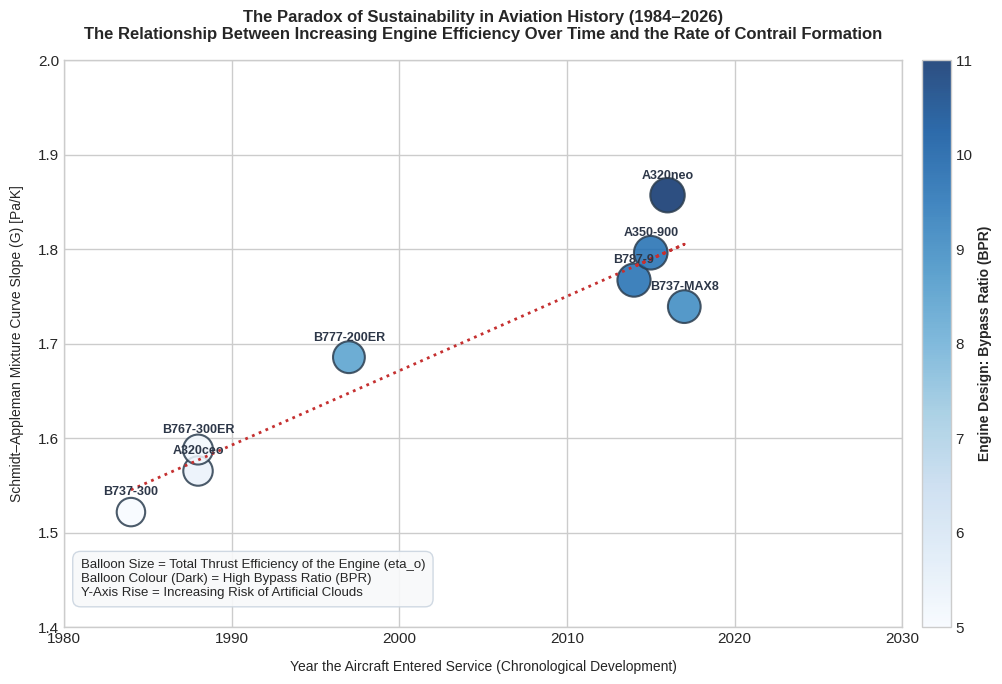

In [ ]:
# Visualization :
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(11, 7), dpi=100)

# Adjusting balloon sizes for optimal readability (scaling for visual clarity):
bubble_sizes = df['Overall_Efficiency'] * 1500

# Scatter plot: X=Year, Y=Cloud slope, Renk=BPR, Boyut=efficiency
scatter = ax.scatter(
    x=df['Service_Year'],
    y=df['SAC_Slope_G'],
    s=bubble_sizes,
    c=df['Bypass_Ratio'],
    cmap='Blues',
    alpha=0.85,
    edgecolors='#2c3e50',
    linewidths=1.5
)

# Trend line (to illustrate technological shifts over time):
m, b = np.polyfit(df['Service_Year'], df['SAC_Slope_G'], 1)
ax.plot(df['Service_Year'], m*df['Service_Year'] + b, color='#c53030', linestyle=':', linewidth=2, label='Teknolojik Trend Çizgisi')

# adding aeroplane models to the top of/beside the balloons:
for i, txt in enumerate(df['Aircraft_Model']):
    ax.annotate(
        txt,
        (df['Service_Year'][i], df['SAC_Slope_G'][i]),
        textcoords="offset points",
        xytext=(0,12),
        ha='center',
        fontsize=9,
        weight='bold',
        color='#2d3748'
    )

# Graph details and colour scale(colour bar)
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Engine Design: Bypass Ratio (BPR)', fontsize=10, weight='semibold')

# Titles and axis informations
ax.set_title('The Paradox of Sustainability in Aviation History (1984–2026)\nThe Relationship Between Increasing Engine Efficiency Over Time and the Rate of Contrail Formation', fontsize=12, pad=15, weight='bold')
ax.set_xlabel('Year the Aircraft Entered Service (Chronological Development)', fontsize=10, labelpad=10)
ax.set_ylabel('Schmidt–Appleman Mixture Curve Slope (G) [Pa/K]', fontsize=10, labelpad=10)

# In-chart label box (like legend)
info_text = (
    "Balloon Size = Total Thrust Efficiency of the Engine (eta_o)\n"
    "Balloon Colour (Dark) = High Bypass Ratio (BPR)\n"
    "Y-Axis Rise = Increasing Risk of Artificial Clouds"
)
ax.text(0.02, 0.05, info_text, transform=ax.transAxes, fontsize=9.5,
        verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', alpha=0.9, edgecolor='#cbd5e0'))

ax.set_xlim(1980, 2030)
ax.set_ylim(1.4, 2.0)
plt.tight_layout()

plt.show()

**Figure 3 (Dual-Axis Contrast Chart):** A dual-axis contrast chart illustrating how the risk of artificial cloud seeding is increasing while carbon emission trends are falling

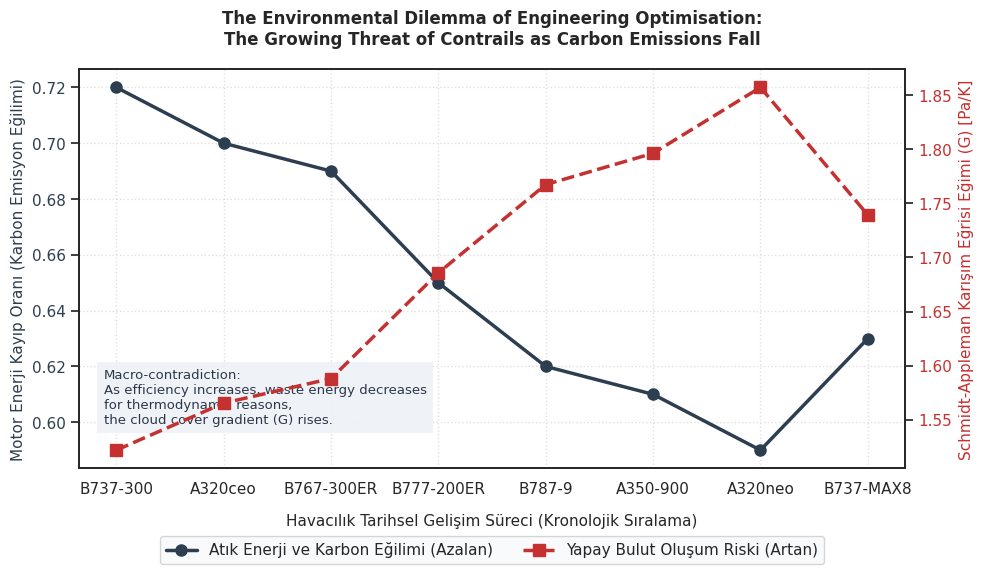

In [ ]:
# aircraft sorted by year:
df = df.sort_values('Service_Year').reset_index(drop=True)

# DUAL-AXIS visualisation
sns.set_theme(style="white") # Arka planı temiz tutmak için white seçtik
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=100)

# First line: Fuel loss / Carbon trend (left-hand axis)
color_carbon = '#2c3e50'
ax1.set_xlabel('Havacılık Tarihsel Gelişim Süreci (Kronolojik Sıralama)', fontsize=11, labelpad=12)
ax1.set_ylabel('Motor Enerji Kayıp Oranı (Karbon Emisyon Eğilimi)', color=color_carbon, fontsize=11)
line1 = ax1.plot(df['Aircraft_Model'], df['Energy_Waste_Factor'], color=color_carbon, marker='o',
                 linewidth=2.5, markersize=8, label='Atık Enerji ve Karbon Eğilimi (Azalan)')
ax1.tick_params(axis='y', labelcolor=color_carbon)
ax1.grid(True, linestyle=':', alpha=0.6)

# Creating a second axis (the right-hand axis)
ax2 = ax1.twinx()

# Second line: Artificial cloud cover ratio (right-hand axis)
color_contrail = '#c53030'
ax2.set_ylabel('Schmidt-Appleman Karışım Eğrisi Eğimi (G) [Pa/K]', color=color_contrail, fontsize=11)
line2 = ax2.plot(df['Aircraft_Model'], df['SAC_Slope_G'], color=color_contrail, marker='s',
                 linewidth=2.5, markersize=8, linestyle='--', label='Yapay Bulut Oluşum Riski (Artan)')
ax2.tick_params(axis='y', labelcolor=color_contrail)


plt.title('The Environmental Dilemma of Engineering Optimisation:\nThe Growing Threat of Contrails as Carbon Emissions Fall',
          fontsize=12, pad=18, weight='bold')

# Combining lines from two different axes into a single legend box=
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=2, frameon=True, facecolor='#f8f9fa')

# note in the graph:
paradox_note = "Makro Çelişki:\nVerimlilik arttıkça atık enerji düşüyor\namat termodinamik nedenlerle\nbulutlanma eğimi (G) kaçınılmaz olarak yükseliyor."
ax1.text(0.03, 0.25, paradox_note, transform=ax1.transAxes, fontsize=9.5, color='#2d3748',
        verticalalignment='top', bbox=dict(boxstyle='square,pad=0.5', facecolor='#edf2f7', alpha=0.85, edgecolor='none'))

plt.tight_layout()
plt.show()